<a href="https://colab.research.google.com/github/aiyman14/DACSS-758-Text-as-Data/blob/main/Week7LabPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with Local Embeddings

In [1]:
# install gensim
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.2 MB/s eta 0:00:00


In [2]:
# for training doc2vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
# for preprocessing
from gensim.parsing.preprocessing import preprocess_string, strip_tags, strip_punctuation, strip_short
from gensim.parsing.preprocessing import strip_multiple_whitespaces, strip_numeric, remove_stopwords
# for dimensionality reduction
from sklearn.decomposition import PCA
# for plotting
import matplotlib.pyplot as plt

In [3]:
# read in txt file (uploaded directly to Colab)
text_file = open("/content/prideprejudice (1).txt", "r", encoding="utf-8")
prideprej = text_file.readlines()
text_file.close()

In [4]:
prideprej[9]

'It is a truth universally acknowledged, that a single man in possession\n'

In [5]:
# preprocess all at once!
prideprej_lower = [item.lower() for item in prideprej]
CUSTOM_FILTERS = [strip_punctuation, strip_multiple_whitespaces, remove_stopwords, strip_short]
prideprej_toks = [preprocess_string(item, CUSTOM_FILTERS) for item in prideprej_lower]
print(prideprej_toks[9])

['truth', 'universally', 'acknowledged', 'single', 'man', 'possession']


In [6]:
# create numeric tag for each document
tagged_docs = [TaggedDocument(words=doc,
                              tags=[str(i)]) for i, doc in enumerate(prideprej_toks)]

In [7]:
# initialize the model
model = Doc2Vec(vector_size=50, min_count=1, epochs=20,
                window=6, negative=10, seed=2026)
# build the vocabulary
model.build_vocab(tagged_docs)
# train the model
model.train(tagged_docs, total_examples=model.corpus_count, epochs=model.epochs)

In [8]:
model.wv.most_similar(positive=['sister'], topn=10)

[('seeing', 0.9833477735519409),
 ('instantly', 0.9813992381095886),
 ('write', 0.9813151359558105),
 ('immediately', 0.9797249436378479),
 ('gone', 0.9789190292358398),
 ('home', 0.9788225293159485),
 ('taken', 0.9782406091690063),
 ('little', 0.9778857827186584),
 ('satisfaction', 0.9777345657348633),
 ('occasion', 0.977373480796814)]

In [9]:
model.wv.most_similar(negative=['sister'], topn=10)

[('confide', 0.456931471824646),
 ('generations', 0.2557258903980255),
 ('chapter', 0.2539353668689728),
 ('avenue', 0.23556841909885406),
 ('energetic', 0.22978749871253967),
 ('desert', 0.20055554807186127),
 ('thoughtful', 0.18516896665096283),
 ('copied', 0.08225011080503464),
 ('wavering', 0.020933672785758972),
 ('reluctance', 0.017396507784724236)]

In [10]:
# vector(family) - vector(marry)
model.wv.most_similar(positive=['family'],
                      negative=['marry'], topn=10)

[('lady', 0.52809077501297),
 ('roads', 0.3881853520870209),
 ('miss', 0.3870398700237274),
 ('bennet', 0.3697530925273895),
 ('bourgh', 0.3671828508377075),
 ('calculate', 0.32665589451789856),
 ('lucas', 0.31810712814331055),
 ('metcalf', 0.30377253890037537),
 ('played', 0.29188910126686096),
 ('collins', 0.283296138048172)]

In [11]:
# finding similar documents
print(prideprej[9])
# look for the most similar document to the 9th document in corpus
similar_docs = model.dv.most_similar([model.dv[9]])
print(similar_docs)
doc_index = [int(item[0]) for item in similar_docs]
similar_docs_text = [prideprej[i] for i in doc_index]
similar_docs_text

It is a truth universally acknowledged, that a single man in possession

[('9', 1.0), ('2847', 0.9629929065704346), ('1674', 0.9501423835754395), ('11400', 0.9485362768173218), ('8189', 0.948230504989624), ('5759', 0.9478793144226074), ('12117', 0.941841185092926), ('2853', 0.9415468573570251), ('8323', 0.9406818151473999), ('9109', 0.9404231905937195)]


['It is a truth universally acknowledged, that a single man in possession\n',
 '"He is a sweet-tempered, amiable, charming man. He cannot know what Mr.\n',
 'dependent on chance as that of any man I know; and if, as you were\n',
 'pleasing, than any other man."\n',
 'ideas. That he was not a good-tempered man had been her firmest opinion.\n',
 'readiness and ease of a well-bred man, and talked very pleasantly; but\n',
 'gentleman is blessed, in a peculiar way, with every thing the heart of\n',
 'a very different man from what he is to the less prosperous. His\n',
 'might it not strike so vain a man! It might seem as if she had purposely\n',
 'such a man to be worked on? How are they even to be discovered? I have\n']

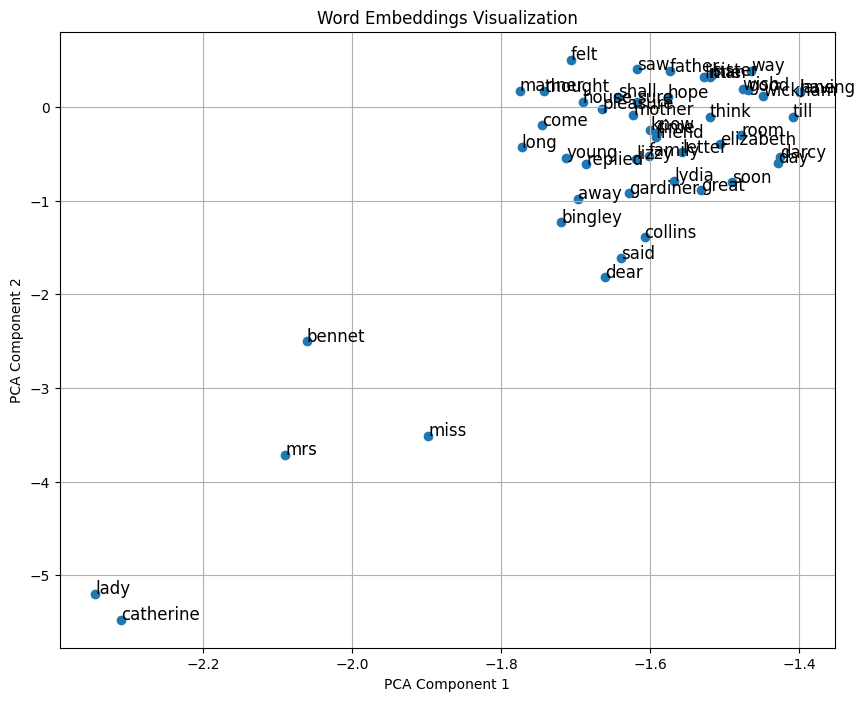

In [12]:
# Reduce dimensionality of word vectors for visualization
word_vectors = model.wv[model.wv.index_to_key]  # Get the word vectors
pca = PCA(n_components=2)  # Initialize PCA
result = pca.fit_transform(word_vectors)  # Fit and transform the word vectors

# Decide number of words to plot
num_words = 50

# Plot the words in a 2D space
plt.figure(figsize=(10, 8))
plt.scatter(result[0:num_words, 0], result[0:num_words, 1])

# Annotate words in the plot
words = list(model.wv.index_to_key)[0:num_words]
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

# Working with Pre-Trained Embeddings

In [13]:
# download and load pretrained model
import gensim.downloader as api

model_gigaword = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [14]:
# previous algebra
model_gigaword.most_similar(positive=['sister'], topn=10)

[('daughter', 0.8687512874603271),
 ('mother', 0.8647425174713135),
 ('wife', 0.8372182846069336),
 ('daughters', 0.7978368401527405),
 ('niece', 0.7832933068275452),
 ('sisters', 0.7734189033508301),
 ('aunt', 0.7558452486991882),
 ('cousin', 0.7551534175872803),
 ('husband', 0.7548229694366455),
 ('father', 0.7548134922981262)]

In [15]:
# previous algebra
model_gigaword.most_similar(negative=['sister'], topn=10)

[('biostratigraphy', 0.5746532678604126),
 ('microtechnology', 0.5481516122817993),
 ('biophotonics', 0.5403603911399841),
 ('compensators', 0.5376269817352295),
 ('in-process', 0.5346002578735352),
 ('4,322', 0.5335602164268494),
 ('limousins', 0.5284801125526428),
 ('re-sale', 0.5254700779914856),
 ('thiourea', 0.5250756740570068),
 ('non-players', 0.5225223302841187)]

In [16]:
# previous algebra
model_gigaword.most_similar(positive=['family'],
                            negative=['marry'], topn=10)

[('carabidae', 0.44876110553741455),
 ('farm', 0.43043869733810425),
 ('arctiidae', 0.4268867075443268),
 ('lycaenidae', 0.41941121220588684),
 ('headquarters', 0.418500155210495),
 ('hesperiidae', 0.4130859673023224),
 ('cerambycidae', 0.40944209694862366),
 ('pieridae', 0.4073333144187927),
 ('geometridae', 0.4040551781654358),
 ('warehouse', 0.402235746383667)]

In [17]:
# "biased" based on training data
model_gigaword.most_similar(positive=['doctor', 'woman'],
                            negative=['man'], topn=10)

[('nurse', 0.7735227942466736),
 ('physician', 0.7189430594444275),
 ('doctors', 0.6824328303337097),
 ('patient', 0.6750683188438416),
 ('dentist', 0.6726033091545105),
 ('pregnant', 0.6642459630966187),
 ('medical', 0.6520450115203857),
 ('nursing', 0.645348072052002),
 ('mother', 0.63933265209198),
 ('hospital', 0.6387495994567871)]